# Inflation Nowcasting — Replication Skeleton
**Knotek & Zaman (2014), Cleveland Fed WP 14-03** · companion to `ROADMAP.md` (the plan) and `paper_reference.md` (the ground truth).

You implement every `TODO`. Self-test cells are provided — green means move on.
Solutions live in `solutions/` — rules for opening them are in ROADMAP.md.
Requires internet on the first run: official FRED API if `FRED_API_KEY` is set (see the M0 walkthrough below), else a no-key fallback endpoint. Series are cached in `data/` so later runs work offline. Python: pandas, numpy, statsmodels, matplotlib (+ scikit-learn for M8).

In [15]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (10, 3.5)

## M0 — Data (provided)

### How the data download works — FRED API walkthrough

**FRED** (Federal Reserve Economic Data, St. Louis Fed) has an official REST API: every request is just a URL like
`https://api.stlouisfed.org/fred/series/observations?series_id=CPIAUCSL&api_key=YOUR_KEY&file_type=json`
— authenticated by a free API key, rate-limited at ~120 requests/minute (we make 8–9). The **`fredapi`** package is a thin Python wrapper around it: `Fred(api_key=...).get_series("CPIAUCSL")` returns a pandas Series. It's already installed in the anaconda3 environment.

Why the official API instead of the old `fredgraph.csv` no-key trick: it's documented and stable, exposes series metadata, and — crucial for **M7** — serves ALFRED *real-time vintages* via `Fred(...).get_series_as_of_date(code, date)` (what the data looked like on a given day, before revisions).

**One-time setup** (the key lives in your shell, never in this notebook — this folder is shared with AI tutor sessions and pushed to GitHub):

1. Get a key at <https://fred.stlouisfed.org/docs/api/api_key.html> (done).
2. In a terminal: `echo 'export FRED_API_KEY="YOUR_KEY"' >> ~/.zshrc`, then open a **fresh** terminal and restart Jupyter from it — Jupyter only sees env vars that existed when it launched.
3. Sanity check in a cell: `import os; print(os.environ.get("FRED_API_KEY") is not None)` → `True`.

**Caching:** each series is saved to `data/<CODE>.csv` on first download, so re-running the notebook is instant and works offline. The trade-off: the cache freezes the data at download time. After a new CPI/PCE release — or for genuinely *live* nowcasting — re-fetch with `fetch_fred(code, refresh=True)`, or just delete the `data/` folder. (`data/` is git-ignored.)

In [16]:
# --- M0 (provided): data download -------------------------------------------
# Preferred path: official FRED API via `fredapi`, key in the FRED_API_KEY env
# var (setup: see the walkthrough cell above). Falls back to FRED's unofficial
# no-key CSV endpoint if the key is missing. Series are cached in data/ so
# reruns work offline; pass refresh=True after new data releases.

import os
from pathlib import Path

FRED_API_KEY = os.environ.get("FRED_API_KEY")
CACHE_DIR = Path("data")
CACHE_DIR.mkdir(exist_ok=True)


def fetch_fred(code: str, start: str = "1993-01-01", refresh: bool = False) -> pd.Series:
    cache = CACHE_DIR / f"{code}.csv"
    if cache.exists() and not refresh:
        s = pd.read_csv(cache, index_col=0, parse_dates=True).iloc[:, 0]
    else:
        if FRED_API_KEY:
            from fredapi import Fred
            s = Fred(api_key=FRED_API_KEY).get_series(code, observation_start=start)
        else:
            url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={code}"
            s = pd.read_csv(url, index_col=0, parse_dates=True).iloc[:, 0]
        s.to_frame(code).to_csv(cache)
    s = pd.to_numeric(s, errors="coerce").dropna()
    s.name = code
    return s[s.index >= start]

CODES = {
    "cpi":      "CPIAUCSL",        # CPI all items, SA, monthly
    "core_cpi": "CPILFESL",        # CPI ex food & energy, SA, monthly
    "food_cpi": "CPIUFDSL",        # CPI food, SA, monthly
    "gas_cpi":  "CUSR0000SETB01",  # CPI gasoline (all types), SA, monthly
    "pce":      "PCEPI",           # PCE price index, monthly
    "core_pce": "PCEPILFE",        # core PCE price index, monthly
    "gas_wk":   "GASALLW",         # EIA retail gasoline, all grades, NSA, weekly
    "oil":      "DCOILBRENTEU",    # Brent crude spot, daily
}

LVL = {k: fetch_fred(v) for k, v in CODES.items()}
print("source:", "official FRED API" if FRED_API_KEY else
      "no-key CSV fallback (set FRED_API_KEY to use the official API)")
for k, s in LVL.items():
    print(f"{k:9s} {s.index[0].date()} -> {s.index[-1].date()}  n={len(s)}")

source: official FRED API
cpi       1993-01-01 -> 2026-05-01  n=400
core_cpi  1993-01-01 -> 2026-05-01  n=400
food_cpi  1993-01-01 -> 2026-05-01  n=400
gas_cpi   1993-01-01 -> 2026-05-01  n=401
pce       1993-01-01 -> 2026-05-01  n=401
core_pce  1993-01-01 -> 2026-05-01  n=401
gas_wk    1993-04-05 -> 2026-07-06  n=1736
oil       1993-01-04 -> 2026-07-06  n=8488


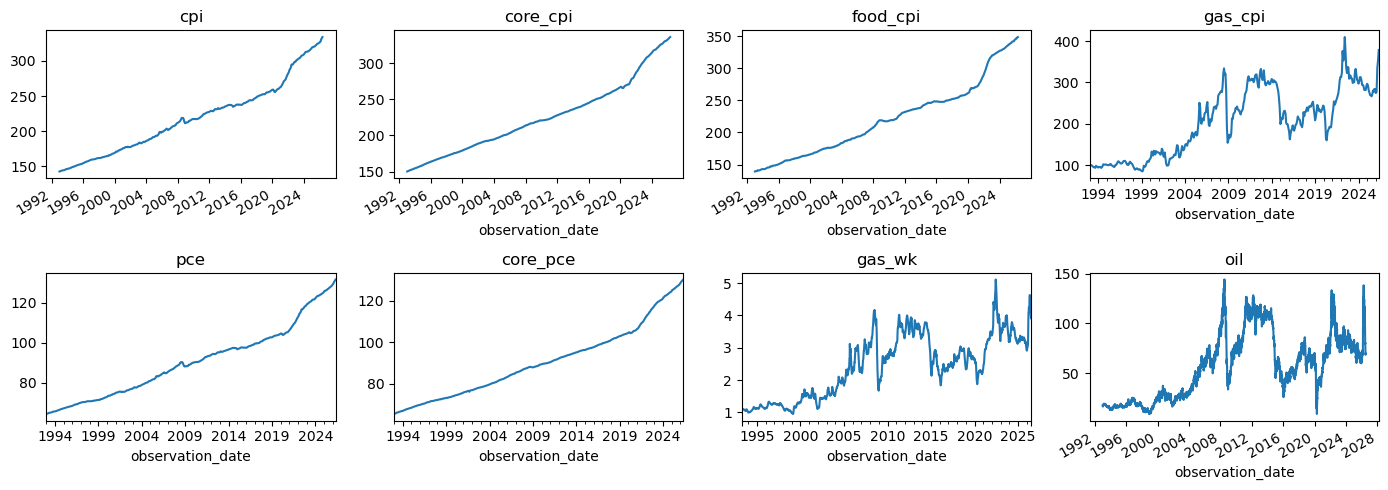

M0 OK — 6 monthly, 1 weekly, 1 daily series


In [17]:
# ### Self-test M0 (provided — do not edit) ###
assert len(LVL) == 8
for k in ["cpi", "core_cpi", "food_cpi", "gas_cpi", "pce", "core_pce"]:
    assert LVL[k].index.freqstr or (LVL[k].index.to_series().diff().dt.days.dropna().between(28, 31).mean() > 0.95), k
assert LVL["gas_wk"].index.to_series().diff().dt.days.dropna().mode()[0] == 7
assert LVL["oil"].index.to_series().diff().dt.days.dropna().mode()[0] == 1
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, (k, s) in zip(axes.flat, LVL.items()):
    s.plot(ax=ax, title=k)
plt.tight_layout(); plt.show()
print("M0 OK — 6 monthly, 1 weekly, 1 daily series")

### ✍️ Checkpoint M0 — answer in writing before continuing

Why does the paper use SA data everywhere except weekly retail gasoline? What breaks if you mix SA and NSA in the same regression?

**My answers:**

- Because the authors are aggregating weekly retail gasoline price to monthly, and then reverse-engineer what's in the CPI gasoline index to seasonally adjust this NSA data. Altogether, they are using all SA data. If SA and NSA are mixed, then seasonal factors sneak into the model, which reduce the accuracy and might increase volatility. 


## M1 — Inflation arithmetic (paper eqs 1–2)

In [5]:
def monthly_inflation(levels: pd.Series) -> pd.Series:
    """Month-over-month inflation in PERCENT (not annualized).
    Input: monthly price levels. Output: 100*(P_t/P_{t-1} - 1)."""
    # TODO(M1): ~1 line
    return 100 * (levels / levels.shift(1) - 1)

def quarterly_annualized(levels: pd.Series) -> pd.Series:
    """Quarterly annualized inflation per paper eqs (1)-(2).
    Step 1: quarterly level = MEAN of the 3 monthly levels
            (hint: levels.groupby(levels.index.to_period("Q")).mean()).
    Step 2: 100 * ((Q_T / Q_{T-1})**4 - 1)."""
    # TODO(M1): ~3 lines
    quarterly = levels.groupby(levels.index.to_period("Q")).mean()
    return 100 * ((quarterly / quarterly.shift(1)) ** 4 - 1)

In [6]:
# ### Self-test M1 (provided — do not edit) ###
# Cross-check against BEA's own quarterly PCE price index (independent series).
pcectpi = fetch_fred("PCECTPI")
bea_q = (100 * ((pcectpi / pcectpi.shift(1)) ** 4 - 1)).dropna()
bea_q.index = bea_q.index.to_period("Q")
mine = quarterly_annualized(LVL["pce"]).dropna()
common = mine.index.intersection(bea_q.index)[-20:]
gap = (mine[common] - bea_q[common]).abs()
print(gap.describe())
assert gap.max() < 0.2, "quarterly aggregation does not match BEA convention"
print("M1 OK — your eq(1)-(2) matches BEA's published quarterly PCE inflation")

count    2.000e+01
mean     1.530e-03
std      8.037e-04
min      5.049e-06
25%      1.103e-03
50%      1.191e-03
75%      2.233e-03
max      2.584e-03
dtype: float64
M1 OK — your eq(1)-(2) matches BEA's published quarterly PCE inflation


### ✍️ Checkpoint M1 — answer in writing before continuing

1. Why does averaging three monthly *levels* differ from averaging three monthly *rates*?
2. Which months of quarter T−1 still influence quarter T inflation, and why does that give the model a head start before T begins?

**My answers:**

- averaging three monthly rates gives us a sense of the average inflationary pace of the quarter, but it does not differentiate between the timing of the inflation shock. averaging the levels gives us the quarterly level, and by averaging, we are taking into account the shock. we can then divide by the previous quarter level and see quarterly inflation and get the annualized inflation.
- month 3 enters both the numerator (head start of T) and the denominator (as the last month of T-1), and month 2 enters the denominator, so these two months are carried over. Month 1 is treated as the base (100) and so the inflation rate of month 1 does not impact the inflation rate of the quarter. However if month 1 of T sees a gasoline price spike, then month 1 of T has a large impact in the average value and thus affect T. (110 110 110) => 1.1^4-1=46.41% even if inflation rate of month 2 and 3 stays the same. (100 100 110) => 1.03^4-1=14.01%. Month 3's spike is not fully reflected in this quarter and is thus carried over to the next quarter.


### 📐 M1 worked examples (tutoring session 2026-07-14)

Reference notes for the three mechanisms behind eqs (1)–(2). All numbers hand-checked during the session.

#### 1. Annualization = repeating the growth factor (why $(\cdot)^4$, not $\times 4$)

"Annualized" means: *if this period's pace continued for a full year, what would the year's total growth be?* A quarterly rate $g$ multiplies the level by $(1+g)$ each quarter, so over four quarters:

$$P_4 = P_0(1+g)^4 \quad\Rightarrow\quad \pi^{\text{ann}} = (1+g)^4 - 1$$

With $g = 0.5\%$: $(1.005)^4 - 1 = 2.015\% \ne 4 \times 0.5\% = 2.0\%$. The gap is compounding — each quarter's growth is charged on an already-grown base. Growth **factors** multiply; growth **rates** don't add. Same logic monthly: $0.2\%$ m/m $\Rightarrow (1.002)^{12} - 1 \approx 2.43\%$. The gap grows with the rate: $10\%$ quarterly gives $46.4\%$ compounded vs $40\%$ naive — and gasoline-driven headline months swing big, which is this paper's subject.

#### 2. Averaging levels vs averaging rates (checkpoint Q1)

Two quarters, both starting from level 100, both containing one $+10\%$ month and two $0\%$ months — only the **timing** differs:

| | monthly levels | mean of monthly rates | quarterly level $\bar{P}_T$ (eq 1) | $\pi_T$ vs prior quarter at 100 (eq 2) |
|---|---|---|---|---|
| Path A (early jump) | 100, 110, 110 | $3.33\%$ | $106.67$ | $(1.0667)^4 - 1 = 29.5\%$ |
| Path B (late jump) | 100, 100, 110 | $3.33\%$ | $103.33$ | $(1.0333)^4 - 1 = 14.0\%$ |

The rates-average is identical — it measures the quarter's average pace but is **timing-blind**. The levels-average counts every month spent at the high level (Path A spends two months there, Path B one), so it encodes *when within the quarter* the shock hit. That's why eq (1) averages levels — and why the within-quarter timing of a gasoline spike matters for quarterly inflation.

#### 3. Carryover: the model's head start (checkpoint Q2)

Let quarter $T{-}1$ have levels $100, 102, 104$ and let prices **freeze** at $104$ through all of quarter $T$ (zero inflation for three months). Then

$$\pi_T = \left(\frac{\bar{P}_T}{\bar{P}_{T-1}}\right)^4 - 1 = \left(\frac{104}{102}\right)^4 - 1 = 8.08\%$$

— nonzero despite *nothing happening* in $T$. The driver is the gap between where $T{-}1$ **ended** ($104$) and where it **averaged** ($102$). This carryover component,

$$\left(\frac{P_{T-1,3}}{\bar{P}_{T-1}}\right)^4 - 1,$$

is fully known on day one of quarter $T$, before any $T$ data exists — pure arithmetic, no autocorrelation needed. Month 3 of $T{-}1$ plays a **dual role**: one-third of the denominator *and* the launch level for the entire numerator. Month 2 enters only the denominator; month 1's *level* also enters the denominator, but its inflation *rate* gets zero weight.

**Bonus — triangle weights** (standard log-approximation; *not from the paper* — general knowledge, treat accordingly): writing $g$ for monthly log-growth,

$$\pi_T \approx \tfrac{1}{3}g_{T-1,2} + \tfrac{2}{3}g_{T-1,3} + g_{T,1} + \tfrac{2}{3}g_{T,2} + \tfrac{1}{3}g_{T,3}$$

Read off: month 1 of $T{-}1$ has weight $0$; the head start is $\tfrac{1}{3}g_{T-1,2} + \tfrac{2}{3}g_{T-1,3}$; a spike in month 1 of $T$ hits $\pi_T$ at full weight but does **not** carry into $\pi_{T+1}$, while a month-3 spike ($\tfrac{1}{3}$ now) mostly carries over — early spike is this quarter's problem, late spike is next quarter's head start. Session check: $(110,110,110)$ vs prior quarter at $100 \Rightarrow 46.4\%$; $(100,100,110) \Rightarrow 14.0\%$.

## M2 — Core & food default: recursive MA12 (paper eq 4)

In [11]:
def ma12_forecast(infl: pd.Series, n_ahead: int = 1) -> np.ndarray:
    """Paper eq (4): RECURSIVE 12-month moving average forecast.
    'Recursive' = each forecast is appended to the history and used in the
    next step's 12-month average (NOT a frozen trailing window).
    Input: realized monthly inflation (dropna'd). Output: n_ahead forecasts."""
    # TODO(M2): ~6 lines (a list, a loop, np.mean of the last 12)
    values = infl.to_list()
    forecasts = []

    for i in range(n_ahead):
        last_12_avg = np.mean(values[-12:])
        values.append(last_12_avg)
        forecasts.append(last_12_avg)
    return np.array(forecasts)

In [12]:
# ### Self-test M2 (provided — do not edit) ###
const = pd.Series(0.2, index=pd.date_range("2000-01-01", periods=24, freq="MS"))
assert np.allclose(ma12_forecast(const, 6), 0.2), "constant series must forecast itself"

core = monthly_inflation(LVL["core_cpi"]).dropna()
eval_idx = core.loc["2005":"2019"].index
err_ma, err_rw = [], []
for t in eval_idx:
    hist = core.loc[:t].iloc[:-1]          # info: data through t-1 only
    err_ma.append(core[t] - ma12_forecast(hist, 1)[0])
    err_rw.append(core[t] - hist.iloc[-1])
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
print(f"RMSE  MA12: {rmse(err_ma):.4f}   random walk: {rmse(err_rw):.4f}")
assert rmse(err_ma) < rmse(err_rw), "MA12 should beat the monthly random walk (Atkeson-Ohanian logic)"
print("M2 OK")

RMSE  MA12: 0.0728   random walk: 0.0826
M2 OK


### ✍️ Checkpoint M2 — answer in writing before continuing

Why is this naive rule so hard to beat for core inflation at short horizons? What time-series property of core inflation does it exploit?

**My answers:**

- For core inflation, it is a combination of the underlying trend + noise. Fluctuations in noise is disproportionately larger since the underlying trend is relatively stable. Taking the average smooths out the noise, albeit making the headline lagging behind the real-time trend. But because the underlying trend is persistent, shrinking the noise doesn't harm and this naive baseline can beat richer models since those models inevitably factor into some noise. For headline on the other hand, swings in the gasoline price is the signal that we want to capture, so we are not taking the average since it loses important information. 


### 📐 M2 worked notes (tutoring session 2026-07-14)

Session results: `RMSE MA12: 0.0728` vs `random walk: 0.0826` on monthly core CPI, 2005–2019 — the Atkeson–Ohanian result.

#### 1. The recursion, by hand

History's last 12 values average $0.3$.

- Forecast $+1$: $0.3$ (mean of the last 12 realized values).
- Forecast $+2$: mean of a *shifted* window — the oldest realized month drops out, **my own $+1$ forecast takes the newest spot**. That feedback is what "recursive" means (eq 4 uses $J=12$ with forecasts re-entering the average).
- A frozen trailing window (always the same last 12 realized values) is a different, wrong model — it would repeat $0.3$ forever regardless of horizon.

In code, the recursion is one line: `values.append(forecast)` — appending to *the same list you average over*. Dropping the oldest value happens for free because `values[-12:]` just stops reaching it as the list grows.

#### 2. Why the naive rule wins for core: signal-to-noise arithmetic

Decompose monthly core inflation as $\pi_t = \tau_t + \varepsilon_t$: a trend $\tau_t$ that drifts very slowly, plus transitory month-to-month noise $\varepsilon_t$ that is *large relative to how much $\tau$ moves in a month*. The target is $\tau_{t+1} \approx \tau_t$. Compare the two forecasts:

| forecast | value | noise carried | trend freshness |
|---|---|---|---|
| random walk | $\pi_t = \tau_t + \varepsilon_t$ | **all** of last month's $\varepsilon_t$ | perfectly fresh |
| MA12 | $\frac{1}{12}\sum_{j=0}^{11}\pi_{t-j} \approx \bar\tau + \frac{1}{12}\sum\varepsilon_{t-j}$ | variance shrunk $\sim$12-fold | $\sim$6 months stale |

**The trade: averaging divides the noise but lags the trend.** The average of a steadily moving path estimates its *midpoint* — where the trend was ~6 months ago, not where it is now. For core, $\tau$ barely moves in 6 months, so the staleness costs $\approx$ nothing while the noise reduction is large: the noise side of the trade dominates. Richer models struggle to beat this because they must find something that predicts monthly core *noise* — and mostly, nothing does; they end up fitting noise instead.

Two corollaries:
- **When MA12 fails:** when the trend genuinely moves fast (e.g., the 2021–22 surge — one reason the kit's evaluation window stops at 2019).
- **Why headline is different:** gasoline swings are big movements in the **signal itself**, not noise — real, and observable nearly in real time via weekly EIA data. You don't average signal away; you measure it. Hence the paper's architecture: core → humble average (eq 4); headline → regression on timely disaggregates (eq 10).

#### 3. Why RMSE as the metric

From the paper (paper_reference §4): RMSE, with Diebold–Mariano tests on the squared-error differentials; outliers excluded (Sep/Oct 2001 PCE, 2008Q4) rather than switching metrics. The reasons behind the convention (general knowledge, not the paper):

1. **Alignment with estimation:** OLS minimizes squared errors, so squared-error evaluation judges the model by the game it trained on.
2. **Big misses hurt disproportionately:** one $1.0$ pp miss $>$ four $0.25$ pp misses — appropriate when gasoline spikes are where the big misses live.
3. **Units:** the square root returns pp of monthly inflation, so RMSE reads as a typical miss size.
4. **Comparability/testability:** the benchmarks (Blue Chip, SPF, Greenbook) are scored in RMSE, and DM machinery works on MSE differentials.

Alternative: MAE (linear loss, outlier-robust, but indifferent between one big miss and many small ones). RMSE alone can't detect systematic over/under-prediction — that's why the M6 table also prints mean error (bias).

#### 4. Python lessons from this milestone

- `list += x` means "concatenate a **collection**" — it walks the right-hand side item by item, so a single float raises `TypeError` (and a string would silently splice in its characters!). To add one item, say what you mean: `list.append(x)`.
- `pd.Series.to_list()` converts to a plain list; negative slicing `lst[-12:]` takes the last 12 items.
- Honor the docstring's return type: `return np.array(forecasts)`, not the bare list.
- Dead code after `return` never runs — delete leftover `raise NotImplementedError` lines instead of leaving them below the return.

## M3 — The gasoline block (paper eqs 6–7 + footnote 7) — hardest milestone

In [34]:
def weekly_to_monthly(weekly: pd.Series) -> pd.Series:
    """Average weekly observations within each calendar month.
    Return a monthly series indexed by month-START timestamps (to align with FRED)."""
    # TODO(M3a): ~3 lines (groupby to_period("M"), mean, to_timestamp)
    monthly_conversion = weekly.groupby(weekly.index.to_period("M")).mean()
    return monthly_conversion.to_timestamp(how="start")

def seasonally_adjust_gas(nsa_infl: pd.Series, cpi_gas_infl: pd.Series) -> pd.Series:
    """Paper footnote 7. For each month, the seasonal factor is the average of
    (NSA gasoline inflation - SA CPI-gasoline inflation) in the SAME calendar
    month over the PREVIOUS 3 years. Return nsa_infl - sf.
    Careful: no look-ahead — only past years may enter the factor.
    Hint: diff.groupby(diff.index.month).transform(lambda x: x.shift(1).rolling(3).mean())"""
    # TODO(M3b): ~4 lines
    diff = nsa_infl - cpi_gas_infl
    sf = diff.groupby(diff.index.month).transform(lambda x: x.shift(1).rolling(3).mean())
    return nsa_infl - sf

def gas_forecast_from_oil(gas_m: pd.Series, oil_m: pd.Series, oil_hat: float,
                          window: int = 60) -> float:
    """Paper eqs (6)-(7). Two-stage regression on the last `window` months of LEVELS:
    (6) long-run:  gas = alpha + beta*oil            -> fitted gap
    (7) ECM:       d(gas)_t = b*d(oil)_t + c*gap_{t-1}
    Then forecast next month's gas level using oil_hat (random-walk oil forecast).
    Returns the forecasted gasoline price LEVEL for the next month."""
    # TODO(M3c): ~10 lines with statsmodels OLS
    oil_gas = pd.concat({"y": gas_m, "x": oil_m}, axis=1).dropna().iloc[-window:]
    gas_fit = sm.OLS(oil_gas["y"], sm.add_constant(oil_gas["x"])).fit()

    stage2_table = pd.concat({"z": oil_gas["y"].diff(), "lagged_resid": gas_fit.resid.shift(1), "d_oil": oil_gas["x"].diff()}, axis=1).dropna()
    change_gas_fit = sm.OLS(stage2_table["z"], stage2_table[["lagged_resid", "d_oil"]]).fit()
    
    print(f"Coefficient of oil and gas: {gas_fit.params["x"]}")
    print(f"Coefficeint of the residual: {change_gas_fit.params['lagged_resid']}")
    return float(oil_gas["y"].iloc[-1] + change_gas_fit.params["lagged_resid"] * gas_fit.resid.iloc[-1] + change_gas_fit.params["d_oil"] * (oil_hat - oil_gas["x"].iloc[-1])) 

In [35]:
# ### Self-test M3 (provided — do not edit) ###
gas_m = weekly_to_monthly(LVL["gas_wk"])                    # $ / gallon, monthly avg
gas_nsa_infl = monthly_inflation(gas_m)
cpi_gas_infl = monthly_inflation(LVL["gas_cpi"])
gas_sa = seasonally_adjust_gas(gas_nsa_infl, cpi_gas_infl)

common = gas_sa.loc["2000":"2019"].index.intersection(cpi_gas_infl.index)
corr = gas_sa[common].corr(cpi_gas_infl[common])
print(f"corr(SA EIA gasoline inflation, CPI gasoline inflation) = {corr:.3f}")
assert corr > 0.9, "EIA-based SA gasoline inflation should track CPI gasoline closely"

oil_m = weekly_to_monthly(LVL["oil"])                       # daily -> monthly avg
oil_hat = float(LVL["oil"].iloc[-1])                        # random-walk oil forecast
lr_beta = sm.OLS(*[x.iloc[-60:] for x in
                   [pd.concat({"g": gas_m, "o": oil_m}, axis=1).dropna()["g"],
                    sm.add_constant(pd.concat({"g": gas_m, "o": oil_m}, axis=1).dropna()["o"])]]).fit().params.iloc[1]
assert lr_beta > 0, "long-run oil coefficient must be positive"
fcst = gas_forecast_from_oil(gas_m, oil_m, oil_hat)
print(f"next-month gasoline level forecast: {fcst:.2f} (last actual {gas_m.iloc[-1]:.2f})")
assert 0.5 * gas_m.iloc[-1] < fcst < 1.5 * gas_m.iloc[-1], "forecast should be near the last level"
print("M3 OK")

corr(SA EIA gasoline inflation, CPI gasoline inflation) = 0.955
Coefficient of oil and gas: 0.027037985472814805
Coefficeint of the residual: -0.336196753138399
next-month gasoline level forecast: 3.69 (last actual 3.91)
M3 OK


### ✍️ Checkpoint M3 — answer in writing before continuing

1. Why seasonally adjust with CPI-gasoline seasonal factors rather than running X-13 on the EIA series? 
    (a) What series is your SA gasoline nowcast ultimately standing in for, in eq (10)? And whose seasonal adjustment defines that target series — so if you invented your own X-13 factors for the EIA data, whose definition of "seasonal" would disagree with whose? 
    (b) X-13's factors are re-estimated every time data arrives, and revise historical values retroactively — what does that do to a real-time nowcasting exercise that must be reproducible as-of each date?
2. What pump-price behavior does the ECM's gap term capture?
3. Why does the paper use a random walk for oil instead of futures prices (see its footnote 9)?

**My answers:**

- The underlying model for the X-13 is ARIMA, so I guess the authors deliberately want to avoid such model because they don't want to apply AR, differencing, or MA. This is especially true for MA since this is what the sf calculation avoids. It takes the average for each calendar month over the past three years rather than taking the average of all months mixed together over the past three years. Moreover, it gives them control over the window and limit it to three years, which might be a more important reason. 
$\Rightarrow$
(a) I don't really know the answer to this question => BLS defines the seasonal adjustment, so the way we seasonally adjust the gasoline price is to mimic BLS's method/definition, which might disagree with the X-13 model. 
(b) The re-estimated values changes the nowcasting values every time data arrives and make the nowcasting irreproducible. 
- I'm not sure. It captures a linear relationship between oil and gas with a residual that corrects the forecast error.
$\Rightarrow$
1. The coefficient of oil in the regression is 0.027037985472814805, which shows a positive relationshp. If oil crashed, then we would expect pump price to crash as well. Since the pump price stays unchanged (actual [unchanged] − fitted [decreased]), the residual is positive.
2. Δgas would be negative since the price falls to the implied value. 
3. the gap coefficient needs to be positive to encode this behavior. => Δgas is negative while the residual is positve, so the coefficient of the residual needs to be negative (what error correction does). Coefficeint of the residual: -0.336196753138399
4. The gas stations are not instantly reacting to the drop in oil prices because they have bought inventories at prices before the oil prices drop. If they drop the price, they might suffer losses, especially when the customers are very price sensitive and would demand more if they see a drop in pump price. 
- A random walk has better forecast accuracy of near-term oil prices than oil futures prices do. Using a random walk rather than adding an additional variable also helps to keep the model parsimonious.


### 📐 M3 worked notes (tutoring session 2026-07-15/16)

Session results: `corr(SA EIA gas infl, CPI gas infl) = 0.955`; next-month gasoline forecast `3.69` vs last actual `3.91`; ECM gap coefficient `c = −0.336`.

#### 1. The pipeline (who prepares what)

$$\texttt{gas\_wk} \xrightarrow{\texttt{weekly\_to\_monthly}} \texttt{gas\_m} \xrightarrow{\texttt{monthly\_inflation}} \texttt{nsa\_infl} \xrightarrow{\;-\,sf\;} \texttt{gas\_sa}$$

The **caller** runs the early stages and hands prepared ingredients to each function through its parameters — inside a function, the raw materials are its parameters, period. (Bug I made twice: reaching for `weekly_to_monthly("gas_wk")` inside `seasonally_adjust_gas`, whose signature already receives the finished `nsa_infl`.)

#### 2. Seasonal factors: the calendar-month bucket trick (footnote 7)

$$sf(m, y) = \frac{1}{3}\sum_{k=1}^{3}\big(\pi^{NSA}_{m,\,y-k} - \pi^{CPI\text{-}gas}_{m,\,y-k}\big), \qquad \pi^{SA}_{m,y} = \pi^{NSA}_{m,y} - sf(m,y)$$

- `groupby(diff.index.month)` buckets by **calendar month number 1–12** — all Januaries together, one entry per *year* inside each bucket. Contrast `to_period("M")`: there `2005-01 ≠ 2006-01` (used in M3a to average weeks within one specific month); here they share the label `1`.
- Because bucket neighbors are a year apart, `rolling(3)` = the past **3 years'** same-calendar-month gaps (not 36!), and `shift(1)` = "previous year's same month" — the current month never enters its own factor: no look-ahead.
- **Why CPI-gas factors instead of X-13 on the EIA series:** (a) *consistency with the target* — eq (10)'s gasoline regressor is CPI-gasoline, seasonally adjusted **by BLS**; the nowcast's job is to impersonate that series, so it must speak BLS's seasonal language. `NSA EIA − SA CPI-gas` measures BLS's seasonal component *as applied* and inherits it by subtraction. (b) *real-time reproducibility* — X-13 factors are re-estimated and revised retroactively; the 3-year backward average is frozen as-of each date. (General-knowledge aside, not from the paper: X-13 is a *framework* — input series, decomposition type, outlier treatment, and vintage are all choices, so "run X-13" doesn't pin down BLS's answer.)

#### 3. The ECM: a machine with two input slots (eqs 6–7)

Stage 1 (levels, 60m): $gas = \alpha + \beta \cdot oil + \varepsilon$ → fitted = "oil-implied fair pump price"; $gap = actual - fitted$.
Stage 2 (changes, no constant): $\Delta gas_t = b\,\Delta oil_t + c\, gap_{t-1}$.

- **Estimation time** teaches the machine from history: every $\Delta gas_t$ paired with *its own* month's $\Delta oil_t$ and *previous* month's gap (`shift(1)` = shift the whole series).
- **Forecast time** feeds the machine next month's slot values: $\Delta oil = oil\_hat - oil_{last}$ (random-walk oil ⇒ ≈ 0 news; footnote 9: hard to beat for near-term oil, and parsimonious) and the **newest** gap (`.iloc[-1]` — no extra shift: the latest residual already *is* the lagged gap of the forecast month). Output is a *change*; add the last level to get the level.
- **Sign logic (checkpoint Q2):** oil crashes → fitted crashes, actual pump price hasn't moved → $gap > 0$ → prices subsequently drift *down* toward fair value → $\Delta gas < 0$ ⇒ **$c < 0$**. Fitted value: $c = -0.336$ — about ⅓ of any mispricing corrected per month. Positive $c$ would mean deviations amplify — no error *correction* at all. Economics: stations bought inventory at old input costs and adjust retail prices gradually rather than instantly.

#### 4. Reference implementation of eq (6)–(7) (written after my version passed)

```python
def gas_forecast_from_oil(gas_m, oil_m, oil_hat, window=60):
    lvl = pd.concat({"gas": gas_m, "oil": oil_m}, axis=1).dropna().iloc[-window:]
    lr  = sm.OLS(lvl["gas"], sm.add_constant(lvl["oil"])).fit()            # eq (6)
    ecm_data = pd.concat({"dgas": lvl["gas"].diff(), "doil": lvl["oil"].diff(),
                          "gap_lag": lr.resid.shift(1)}, axis=1).dropna()
    ecm = sm.OLS(ecm_data["dgas"], ecm_data[["doil", "gap_lag"]]).fit()    # eq (7), no constant
    return float(lvl["gas"].iloc[-1]
                 + ecm.params["doil"] * (oil_hat - lvl["oil"].iloc[-1])
                 + ecm.params["gap_lag"] * lr.resid.iloc[-1])
```

All estimation inputs flow from the one windowed table `lvl`, so the 60-month discipline holds by construction; the return line reads term-by-term like the forecast formula.

#### 5. Python lessons from this milestone

- **Two-column selection is brackets-inside-brackets**: `df[["a", "b"]]`. Writing `df["a", "b"]` makes ONE tuple key → `KeyError: ('a', 'b')`.
- **`params` is answered with strings** (`fit.params["doil"]`), data tables with lists of strings. A non-string inside `params[...]` is always wrong.
- **`shift(1)` vs `.iloc[-1]`**: shift moves a whole series (estimation-time pairing); iloc picks one number (forecast-time plug-in). Using shift where a scalar belongs is a category error.
- **`sm.OLS(y, X)` takes exactly two data arguments** — multiple regressors go in as one multi-column X, and `dropna()` belongs to the data *before* the model, never to the OLS object.
- **`.diff()` is a method** (`s.diff()`), and `fit.resid` hands you stage-1 residuals as a ready-made Series.
- **`oil_hat` is a float** — a forecast has no `.diff()`; the forecast-month change is `oil_hat − last observed level`.
- **Run every version before review** — `shfit` typos, float-`.diff()`, and tuple-key errors are all instant interpreter catches.

## M4 — Bridge equations (paper eqs 5 & 9)

In [13]:
def bridge_forecast(y_infl: pd.Series, x_infl: pd.Series, window: int = 24) -> float:
    """Paper eqs (5)/(9): bridge from a released series to an unreleased one.
    Fit OLS  y_t = b + a*x_t  on the last `window` months where BOTH are observed,
    then predict y for the newest month where ONLY x is observed.
    Returns that single predicted value."""
    # TODO(M4): ~5 lines. Careful: same-month pairing, not lagged.
    concat = pd.concat({"y": y_infl, "x": x_infl}, axis = 1).dropna()
    x = sm.add_constant(concat["x"])
    y = concat["y"]
    results = sm.OLS(y.iloc[-window:], x.iloc[-window:]).fit()
    predictions = results.params['const'] + results.params["x"] * x_infl.iloc[-1]
    return predictions

In [14]:
# ### Self-test M4 (provided — do not edit) ###
core_cpi_i = monthly_inflation(LVL["core_cpi"]).dropna()
core_pce_i = monthly_inflation(LVL["core_pce"]).dropna()
eval_idx = core_pce_i.loc["2005":"2019"].index
err_br, err_ma = [], []
for t in eval_idx:
    y_hist = core_pce_i.loc[:t].iloc[:-1]         # PCE not yet out for month t
    x_hist = core_cpi_i.loc[:t]                   # CPI IS out for month t
    err_br.append(core_pce_i[t] - bridge_forecast(y_hist, x_hist))
    err_ma.append(core_pce_i[t] - ma12_forecast(y_hist, 1)[0])
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
print(f"RMSE  bridge: {rmse(err_br):.4f}   MA12: {rmse(err_ma):.4f}")
assert rmse(err_br) < rmse(err_ma), "bridging released core CPI should beat MA12 for core PCE (paper Table 7, line 14)"
print("M4 OK")

RMSE  bridge: 0.0630   MA12: 0.0794
M4 OK


### ✍️ Checkpoint M4 — answer in writing before continuing

1. What do CPI and PCE share that makes a same-month bridge work? Name two reasons they diverge.
2. Why a 24-month window instead of the full sample? (Connect to the bias-variance / regime-change argument.)

**My answers:**

- there are many components of CPI and PCE that overlap, such as gasoline prices and housing prices. As such, CPI contains rich information that could help predict PCE. the first reason they diverge is that they have different weights on different categories. While PCE has higher weight on computer software and accesssories, investment advice, and legal services, CPI has lower weights on these. Moreover, PCE uses chain-weights, that it, the weight adjusts dynamically based on what contributes to the inflation more according to the latest trend, while CPI is fixed throughout the year until annual revision. 
- 24 months is a horizon that typically sees the CPI-PCE relationship drift enough that the old pairs mislead more than they inform. We suffer higher variance by choosing smaller samples in exchange for lower bias, since recent samples give us more accurate information about the current trend.


### 📐 M4 worked notes (tutoring session 2026-07-15)

Session results: `RMSE bridge: 0.0630` vs `MA12: 0.0794` on monthly core PCE, 2005–2019 — bridging the released core CPI beats the pure time-series default by ~20% (the paper's Table 7 line-14 point).

#### 1. What a bridge is (and is not)

Release timing (paper_reference §2): CPI for month $t$ lands mid-month $t{+}1$; PCE for month $t$ lands ~2 weeks later. In that gap, month-$t$ CPI is *known* and month-$t$ PCE is not. Eq (5)/(9): regress $\pi_t^{PCE} = b + a\,\pi_t^{CPI}$ on the last 24 **same-month** pairs, plug in the released CPI value.

- This is a **measurement relationship, not a forecasting one**: two indexes reading the same month's prices through different lenses, one published earlier. No lag anywhere — pairing $y_t$ with $x_{t-1}$ would estimate a lead-lag (Granger-style) relationship, which is a different and wrong model here.
- Why it works: heavily overlapping underlying prices (gasoline, food, housing, ...). Why the fit isn't perfect — the divergence reasons: **different weights** (e.g., shelter weighs far more in CPI; PCE covers categories CPI barely touches) and the **formula effect** (PCE chain-weights adapt to substitution continuously; CPI weights are fixed between revisions).
- **Why 24 months, not the full sample:** the $a, b$ linking the two indexes drift over time. Short window = **higher variance** (24 points → noisy estimates) traded for **lower bias** (only current-regime evidence). Anchor: *long window = precise answer to the old question; short window = noisy answer to the current question.* The paper's evidence that the trade pays: stretching windows to $\tau=120$ raises headline RMSE 16–47% (paper_reference §4).

#### 2. Reference implementation (written after my version passed — for style comparison)

```python
def bridge_forecast(y_infl: pd.Series, x_infl: pd.Series, window: int = 24) -> float:
    both = pd.concat({"y": y_infl, "x": x_infl}, axis=1).dropna().iloc[-window:]
    fit = sm.OLS(both["y"], sm.add_constant(both["x"])).fit()
    return float(fit.params["const"] + fit.params["x"] * x_infl.iloc[-1])
```

Same algorithm as my version; style differences worth stealing:

- **Slice the aligned table once** (`.dropna().iloc[-window:]` chained), *then* split into y and x — the same-rows guarantee is visible in a single expression instead of relying on two separate slices staying in sync.
- **Names carry meaning**: `both` = "months where both exist"; `fit` = "fitted model". Avoid naming a variable after a function or its type (`concat`, `results`).
- **`float(...)` on the return** makes the docstring's contract explicit instead of leaking a numpy scalar.
- The newest x comes from `x_infl.iloc[-1]`, *outside* the aligned table — `.dropna()` (correctly) removed that month from the estimation sample because it has no y partner yet. That asymmetry IS the bridge.

#### 3. Python lessons from this milestone

- **Alignment is `pd.concat(..., axis=1)`**: it matches rows by date index, giving one row per month with both values side by side; `.dropna()` removes incomplete months. Never align two series by slicing them separately — different lengths → different months.
- **`.iloc` vs `.loc` vs `[]`**: `.iloc` = always positional; `.loc` = always label; plain `[]` is context-dependent — on a date-indexed Series, `s[-24:]` (a slice) silently works positionally, but `s[-1]` (a scalar) raises `KeyError` because pandas looks for a *label* `-1`. Same-looking syntax, different rules ⇒ always say what you mean: `.iloc[-1]`.
- **`fit.params` is a Series keyed by column name** — index it with the string `"x"`, not with the `x` DataFrame itself (a table is not a dictionary key).
- **`fit.predict(X)` predicts for whatever rows you hand it** — handing it the estimation table just refits the past. For one new point, build a one-row `[1, x_new]` input or compute $b + a \cdot x_{new}$ from `fit.params` directly (clearer).
- **Run before asking for review** — the interpreter finds `KeyError`-class bugs faster than any reader.

## M5 — Headline regression + deterministic model switching (paper eqs 8–11)

In [ ]:
def choose_regime(have_own_cpi_t: bool, have_gas_t: bool) -> str:
    """Deterministic model switching (the paper's core innovation, eqs 9-11).
    Return one of: "bridge" (eq 9), "disagg_reg" (eq 10), "ma" (eq 11)."""
    # TODO(M5a): 3 lines. Think about precedence: a released CPI beats everything.
    if have_own_cpi_t == True & have_gas_t == True:
        return bridge
    elif have_own_cpi_t == False & have_gas_t == True:
        return disagg_reg
    else:
        return ma

def headline_reg_forecast(y_infl: pd.Series, core_infl: pd.Series,
                          food_infl: pd.Series, gas_infl: pd.Series,
                          core_hat: float, food_hat: float, gas_hat: float,
                          window: int = 24) -> float:
    """Paper eq (10) for ONE headline measure. Note the zero restrictions:
    the CPI equation uses core CPI; the PCE equation uses core PCE; both use
    food and gasoline. Fit OLS  y = b + c1*core + c3*food + c4*gas  on the last
    `window` months where all four are observed; predict with the hats."""
    # TODO(M5b): ~7 lines
    concat_all = pd.concat({"headline": y_infl, "core": core_infl, "food": food_infl, "gas": gas_infl}, axis =1).dropna().iloc[-window:]
    reg = sm.OLS(concat_all["headline"], sm.add_constant(concat_all[["core", "food", "gas"]])).fit()
    prediction = reg.params["const"] + (reg.params["core"] * core_hat) + (reg.params["food"] * food_hat) + (reg.params["gas"] * gas_hat)
    return float(prediction)

In [ ]:
# ### Self-test M5 (provided — do not edit) ###
assert choose_regime(True,  True)  == "bridge"
assert choose_regime(True,  False) == "bridge"
assert choose_regime(False, True)  == "disagg_reg"
assert choose_regime(False, False) == "ma"

cpi_i  = monthly_inflation(LVL["cpi"]).dropna()
food_i = monthly_inflation(LVL["food_cpi"]).dropna()
df = pd.concat({"y": cpi_i, "core": core_cpi_i, "food": food_i, "gas": gas_sa}, axis=1).dropna()
r2 = sm.OLS(df["y"], sm.add_constant(df[["core", "food", "gas"]])).fit().rsquared
print(f"full-sample R2 of eq(10) CPI regression: {r2:.3f}")
assert r2 > 0.5, "core+food+gas should explain most headline CPI variation"
print("M5 OK")

### ✍️ Checkpoint M5 — answer in writing before continuing

Write the regime table from memory: for information states (i) nothing released, no gas; (ii) weekly gas only; (iii) CPI(t) released — which equation governs, and why is this 'time-varying weights' in the eq (3) sense?

**My answers:**

- 


## M6 — Calendar simulation

We evaluate the model at three information dates ("cases") for each target month *t* — a simplified version of the paper's six (Table 2):

| Case | Stand-in date            | CPI thru | PCE thru | EIA gas in month t | Oil        |
|------|--------------------------|----------|----------|--------------------|------------|
| A    | last day of month t−1    | t−2      | t−2      | none               | thru t−1   |
| B    | ~15th of month t         | t−1      | t−2      | first 2 weeks      | thru day 14|
| C    | day after CPI(t) release | t        | t−1      | all weeks          | all        |

Your job: implement `nowcast_month(t, case)` returning nowcasts for all four measures,
respecting ONLY the information in the table (this discipline is the whole exercise).
Then the provided loop computes RMSEs per case. Deviation from the paper (noted in
ROADMAP): we evaluate 2005–2019 on final-vintage data, so error LEVELS won't match the
paper's tables — the declining-RMSE PATTERN is the success criterion.

In [ ]:
# Realized monthly inflation series (info truncation happens inside nowcast_month)
INFL = {
    "cpi":      monthly_inflation(LVL["cpi"]).dropna(),
    "core_cpi": monthly_inflation(LVL["core_cpi"]).dropna(),
    "food":     monthly_inflation(LVL["food_cpi"]).dropna(),
    "pce":      monthly_inflation(LVL["pce"]).dropna(),
    "core_pce": monthly_inflation(LVL["core_pce"]).dropna(),
    "gas_sa":   gas_sa,
}
GAS_M, OIL_D = gas_m, LVL["oil"]


def nowcast_month(t: pd.Timestamp, case: str) -> dict:
    """Nowcast {'cpi','core_cpi','pce','core_pce'} for target month t under case A/B/C.

    Recipe (follow paper_reference.md §3):
      1. Truncate every series to what the case table allows. For case B's partial
         gasoline month: average EIA weeks with day <= 14 in month t.
      2. core_cpi & food: actual if released, else ma12_forecast (recursive, chained
         over however many months are missing).
      3. core_pce: actual if released; bridge_forecast from core_cpi if CPI is one
         month ahead of PCE; else ma12.
      4. gas: SA partial-month estimate if weeks exist (case B/C), else
         gas_forecast_from_oil with a random-walk oil forecast (case A);
         convert the level forecast to inflation, then seasonally adjust.
      5. headline: actual if released (case C cpi); else choose_regime ->
         headline_reg_forecast with the hats from steps 2-4; pce in case C: bridge.
    """
    # TODO(M6): the capstone. ~40 lines. Build it case by case; test case C first
    # (easiest: only PCE measures need nowcasting), then B, then A.
    raise NotImplementedError

In [ ]:
# ### Self-test M6 (provided — do not edit) ###
targets = INFL["pce"].loc["2005":"2019"].index
results, bias, skipped = {}, {}, {}
for case in ["A", "B", "C"]:
    errs = {k: [] for k in ["cpi", "core_cpi", "pce", "core_pce"]}
    n_skip = 0
    for t in targets:
        try:
            nc = nowcast_month(t, case)
        except Exception:
            n_skip += 1
            continue
        for k in errs:
            errs[k].append(nc[k] - INFL[k][t])
    skipped[case] = n_skip
    results[case] = {k: float(np.sqrt(np.mean(np.square(v)))) for k, v in errs.items()}
    bias[case] = {k: float(np.mean(v)) for k, v in errs.items()}
tbl = pd.DataFrame(results).T
print("RMSE by case:"); print(tbl.round(4))
print("\nMean error (bias) by case:"); print(pd.DataFrame(bias).T.round(4))
print(f"\nskipped months per case (of {len(targets)} targets): {skipped}")

tbl[["cpi", "core_cpi"]].plot(kind="bar", title="Monthly nowcast RMSE by case (paper Fig. 2 analogue)")
plt.ylabel("pp, month-over-month"); plt.show()

for case, n_skip in skipped.items():
    assert n_skip <= 0.1 * len(targets), \
        f"case {case}: nowcast_month raised on {n_skip}/{len(targets)} months — fix the errors, don't rely on skips"
assert tbl.loc["C", "cpi"] < tbl.loc["B", "cpi"] < tbl.loc["A", "cpi"], \
    "headline CPI RMSE must fall as information arrives"
assert (tbl.loc["A", "core_cpi"] - tbl.loc["B", "core_cpi"]) < \
       (tbl.loc["A", "cpi"] - tbl.loc["B", "cpi"]), \
    "core should improve far less than headline (gasoline is doing the work)"
print("M6 OK — you have replicated the paper's signature result")

### ✍️ Checkpoint M6 — answer in writing before continuing

Explain in one sentence why core RMSE barely moves from case A to C while headline RMSE falls sharply.

**My answers:**

- 


## M7 — Stretch goals (see ROADMAP.md)

Pick any: ALFRED real-time vintages (`fredapi.Fred.get_series_as_of_date` — the
`FRED_API_KEY` setup from M0 already unlocks this) · Diebold–Mariano tests ·
quarterly aggregation (reuse `quarterly_annualized` and the paper's 14 cases).

The ML extension has been promoted to a full milestone: **M8**, below.

## M8 — Interpretable ML horse-race (ROADMAP M8)

ML models enter only if their fitted behavior can be *read* — coefficients (M8a),
selection sets (M8b), shape functions (M8c). Black boxes appear only as accuracy
ceilings to interpret against. All sklearn; requires M5–M6 to be green (reuses
`headline_reg_forecast`, `INFL`, `gas_sa`).

**Discipline (non-negotiable, inherited from the paper):** any tuning uses data
*before* the forecast date only, and the benchmark to beat is **your eq-(10)
model**, not the random walk.

**The harness** (provided below) evaluates case-B style with *perfect
disaggregates*: every model sees regressor histories through t−1 and the actual
month-t disaggregates as hats. Hat generation is identical across model classes,
so this isolates the question that M8 actually asks: *which regression maps
disaggregates to headline best?*

In [ ]:
# --- M8 (provided): extra data + evaluation harness --------------------------
ML_CODES = {
    "ppi_gas":  "WPS0571",      # PPI gasoline, SA, monthly
    "imports":  "IR",           # import price index, all commodities, NSA, monthly
    "wages":    "AHETPI",       # avg hourly earnings, production workers, SA, monthly
    "gas_spot": "DGASUSGULF",   # Gulf Coast conventional gasoline spot, daily
}
ML_LVL = {k: fetch_fred(v) for k, v in ML_CODES.items()}
ML_INFL = {k: monthly_inflation(weekly_to_monthly(s) if k == "gas_spot" else s).dropna()
           for k, s in ML_LVL.items()}

HARNESS_IDX = INFL["cpi"].loc["2005":"2019"].index
print("harness:", len(HARNESS_IDX), "target months, case-B info, perfect disaggregates")

In [ ]:
def ridge_headline_forecast(y_infl: pd.Series, core_infl: pd.Series,
                            food_infl: pd.Series, gas_infl: pd.Series,
                            core_hat: float, food_hat: float, gas_hat: float,
                            alpha: float = 1.0, window: int = 24) -> float:
    """M8a: paper eq (10) with an L2 penalty (ridge).
    Same recipe as headline_reg_forecast, but:
      - standardize the three regressors with the WINDOW's mean/std only
        (sklearn StandardScaler; scaling on the full sample is leakage),
      - fit sklearn Ridge(alpha=alpha); fit_intercept=True keeps the
        intercept unpenalized (never penalize the intercept),
      - predict with the standardized hats.
    alpha=0 must reproduce the OLS forecast; alpha -> inf collapses to the
    window mean of y."""
    # TODO(M8a): ~8 lines (StandardScaler + Ridge)
    raise NotImplementedError

In [ ]:
# ### Self-test M8a (provided — do not edit) ###
from sklearn.linear_model import Ridge as _Ridge

# 1) limits: alpha=0 == OLS; alpha -> inf == window mean of y
args = (INFL["cpi"], INFL["core_cpi"], INFL["food"], INFL["gas_sa"], 0.2, 0.15, 1.0)
f_ols = headline_reg_forecast(*args)
assert abs(ridge_headline_forecast(*args, alpha=0.0) - f_ols) < 1e-6, "alpha=0 must equal OLS"
wmean = pd.concat({"y": INFL["cpi"], "core": INFL["core_cpi"], "food": INFL["food"],
                   "gas": INFL["gas_sa"]}, axis=1).dropna().iloc[-24:]["y"].mean()
assert abs(ridge_headline_forecast(*args, alpha=1e9) - wmean) < 1e-3, "alpha->inf must collapse to window mean"

# 2) expanding-window-tuned ridge vs eq(10) OLS on the harness (tuning uses PAST errors only)
grid = [0.0, 0.3, 1.0, 3.0, 10.0]
sq = {a: [] for a in grid}
err_tuned, err_ols = [], []
for t in HARNESS_IDX:
    hists = (INFL["cpi"].loc[:t].iloc[:-1], INFL["core_cpi"].loc[:t].iloc[:-1],
             INFL["food"].loc[:t].iloc[:-1], INFL["gas_sa"].loc[:t].iloc[:-1])
    hats = (INFL["core_cpi"][t], INFL["food"][t], INFL["gas_sa"][t])
    preds = {a: ridge_headline_forecast(*hists, *hats, alpha=a) for a in grid}
    if len(sq[0.0]) >= 24:
        a_star = min(grid, key=lambda a: np.mean(sq[a][-24:]))
        err_tuned.append(preds[a_star] - INFL["cpi"][t])
        err_ols.append(preds[0.0] - INFL["cpi"][t])
    for a in grid:
        sq[a].append((preds[a] - INFL["cpi"][t]) ** 2)
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
print(f"harness RMSE  ridge(tuned): {rmse(err_tuned):.4f}   eq(10) OLS: {rmse(err_ols):.4f}")
assert rmse(err_tuned) <= 1.05 * rmse(err_ols), "tuned ridge should not lose to OLS by more than 5%"

# 3) rolling coefficient paths (standardized, so comparable): the instability story
dfp = pd.concat({"y": INFL["cpi"], "core": INFL["core_cpi"],
                 "food": INFL["food"], "gas": INFL["gas_sa"]}, axis=1).dropna()
rows = []
for i in range(24, len(dfp)):
    w = dfp.iloc[i - 24:i]
    Xs = (w[["core", "food", "gas"]] - w[["core", "food", "gas"]].mean()) / w[["core", "food", "gas"]].std()
    ols_g = sm.OLS(w["y"], sm.add_constant(Xs)).fit().params["gas"]
    rdg_g = _Ridge(alpha=10.0).fit(Xs, w["y"]).coef_[2]
    rows.append({"date": dfp.index[i], "OLS": ols_g, "ridge(alpha=10)": rdg_g})
pd.DataFrame(rows).set_index("date").plot(
    title="Rolling 24m gasoline coefficient (standardized): OLS jumps, ridge smooths")
plt.ylabel("coef on gas"); plt.show()
print("M8a OK")

### ✍️ Checkpoint M8a — answer in writing before continuing

1. Why do short rolling windows and shrinkage address the same problem? What is that problem, in this paper's setting?
2. Under what data conditions would ridge on a 60-month window beat OLS on a 24-month window?

**My answers:**

- 


In [ ]:
def lasso_selection(y_infl: pd.Series, X: pd.DataFrame, window: int = 60,
                    step: int = 3) -> pd.DataFrame:
    """M8b: rolling LASSO variable selection.
    For each rolling window of `window` consecutive months (advancing by
    `step` months):
      - standardize X inside the window (full-sample scaling is leakage),
      - fit sklearn LassoCV(cv=TimeSeriesSplit(n_splits=4)) on (X, y),
      - record which columns get nonzero coefficients.
    Return a DataFrame: index = window-end date, columns = X.columns,
    values = bool (selected in that window)."""
    # TODO(M8b): ~10 lines (LassoCV, TimeSeriesSplit, StandardScaler)
    raise NotImplementedError

In [ ]:
# ### Self-test M8b (provided — do not edit) ###
X_wide = pd.concat({
    "core_cpi": INFL["core_cpi"], "food": INFL["food"], "gas_sa": INFL["gas_sa"],
    "ppi_gas": ML_INFL["ppi_gas"], "imports": ML_INFL["imports"],
    "wages": ML_INFL["wages"], "gas_spot": ML_INFL["gas_spot"],
}, axis=1).dropna().loc["2000":"2019"]
y_wide = INFL["cpi"][X_wide.index]

sel = lasso_selection(y_wide, X_wide)
assert list(sel.columns) == list(X_wide.columns) and sel.dtypes.eq(bool).all()
freq = sel.mean().sort_values(ascending=False)
print("selection frequency across windows:")
print(freq.round(2))
gas_family = sel[["gas_sa", "ppi_gas", "gas_spot"]].any(axis=1).mean()
print(f"\ngasoline family (any of gas_sa/ppi_gas/gas_spot) selected in {gas_family:.0%} of windows")
assert gas_family >= 0.8, "a gasoline-family regressor should be selected in >=80% of windows"
print("M8b OK")

### ✍️ Checkpoint M8b — answer in writing before continuing

1. Which regressors survive, and how stable is the selection across windows? Did LASSO rediscover the paper's hand-picked four?
2. The gasoline "twins" (CPI gas, PPI gas, spot gas) are nearly collinear. What does LASSO do with collinear twins, and why does that mean you should report the selection *family*, not the individual pick?

**My answers:**

- 


In [ ]:
def spline_additive_forecast(y_infl: pd.Series, X_hist: pd.DataFrame, x_hat: dict,
                             window: int = 60, n_knots: int = 5,
                             alpha: float = 1.0) -> float:
    """M8c: DIY GAM. One sklearn Pipeline:
    StandardScaler -> SplineTransformer(n_knots=n_knots, degree=3) -> Ridge(alpha).
    SplineTransformer expands EACH feature into its own spline basis, and Ridge
    is linear in that basis, so the model is ADDITIVE:
        y = f_core(core) + f_food(food) + f_gas(gas)
    — nonlinear per feature, but each fitted shape f_j can be plotted and read.
    Fit on the last `window` months where y and all X_hist columns are observed;
    return the prediction at x_hat (a dict keyed by X_hist's columns).
    Note window=60, not 24: splines need more data — a deliberate, disclosed
    deviation from eq (10)'s window."""
    # TODO(M8c): ~7 lines (make_pipeline, fit, predict)
    raise NotImplementedError

In [ ]:
# ### Self-test M8c (provided — do not edit) ###
from sklearn.ensemble import HistGradientBoostingRegressor

X3 = pd.concat({"core": INFL["core_cpi"], "food": INFL["food"],
                "gas": INFL["gas_sa"]}, axis=1).dropna()
y3 = INFL["cpi"]

err = {"spline (DIY GAM)": [], "eq(10) OLS": [], "boosting ceiling": [], "random walk": []}
for t in HARNESS_IDX:
    Xh, yh = X3.loc[:t].iloc[:-1], y3.loc[:t].iloc[:-1]
    hats = {"core": INFL["core_cpi"][t], "food": INFL["food"][t], "gas": INFL["gas_sa"][t]}
    err["spline (DIY GAM)"].append(spline_additive_forecast(yh, Xh, hats) - y3[t])
    err["eq(10) OLS"].append(headline_reg_forecast(yh, Xh["core"], Xh["food"], Xh["gas"],
                                                   hats["core"], hats["food"], hats["gas"]) - y3[t])
    w = pd.concat([yh.rename("y"), Xh], axis=1).dropna().iloc[-60:]
    hgb = HistGradientBoostingRegressor(max_iter=100, random_state=0).fit(
        w[["core", "food", "gas"]], w["y"])
    err["boosting ceiling"].append(float(hgb.predict(pd.DataFrame([hats]))[0]) - y3[t])
    err["random walk"].append(float(yh.iloc[-1]) - y3[t])
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
res = pd.Series({k: rmse(v) for k, v in err.items()}).sort_values()
print("harness RMSE (headline CPI, perfect disaggregates):")
print(res.round(4))
assert res["spline (DIY GAM)"] < res["random walk"], "the additive spline model must beat the monthly random walk"

# gasoline shape function: sweep gas over its range, others held at window medians
w = pd.concat([y3.rename("y"), X3], axis=1).dropna().iloc[-60:]
gas_grid = np.linspace(w["gas"].quantile(0.02), w["gas"].quantile(0.98), 60)
shape = [spline_additive_forecast(w["y"], w[["core", "food", "gas"]],
                                  {"core": w["core"].median(), "food": w["food"].median(),
                                   "gas": g}) for g in gas_grid]
plt.plot(gas_grid, shape); plt.axvline(0, ls=":", c="gray")
plt.xlabel("gasoline inflation (pp, m/m)"); plt.ylabel("predicted headline CPI inflation")
plt.title("DIY-GAM gasoline shape function — look for asymmetry around 0")
plt.show()
print("M8c OK")

### ✍️ Checkpoint M8c — answer in writing before continuing

1. From the fitted gasoline shape function: is the pass-through asymmetric ("rockets and feathers")? How would you tell noise from signal here?
2. Why does additivity keep this model readable while a random forest is not?
3. Did nonlinearity actually pay in RMSE? If not, why might 60 monthly observations be too few for it to?

### ✍️ Closing checkpoint M8

Which of the paper's design choices did you keep in the ML version, and why? (Think: calendar discipline, information sets, past-only tuning, benchmark choice.)

**My answers:**

- 
